## Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris

In [7]:
iris=load_iris()

In [13]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [16]:
X=pd.DataFrame(iris['data'],columns=iris['feature_names'])

In [18]:
y=pd.Series(iris['target'])

In [19]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,Y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [26]:
from sklearn.tree import DecisionTreeClassifier
ds=DecisionTreeClassifier(criterion='gini',max_depth=2)

In [28]:
ds.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.666\nsamples = 112\nvalue = [35, 39, 38]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.5\nsamples = 77\nvalue = [0.0, 39.0, 38.0]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.056\nsamples = 35\nvalue = [0, 34, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.21\nsamples = 42\nvalue = [0, 5, 37]')]

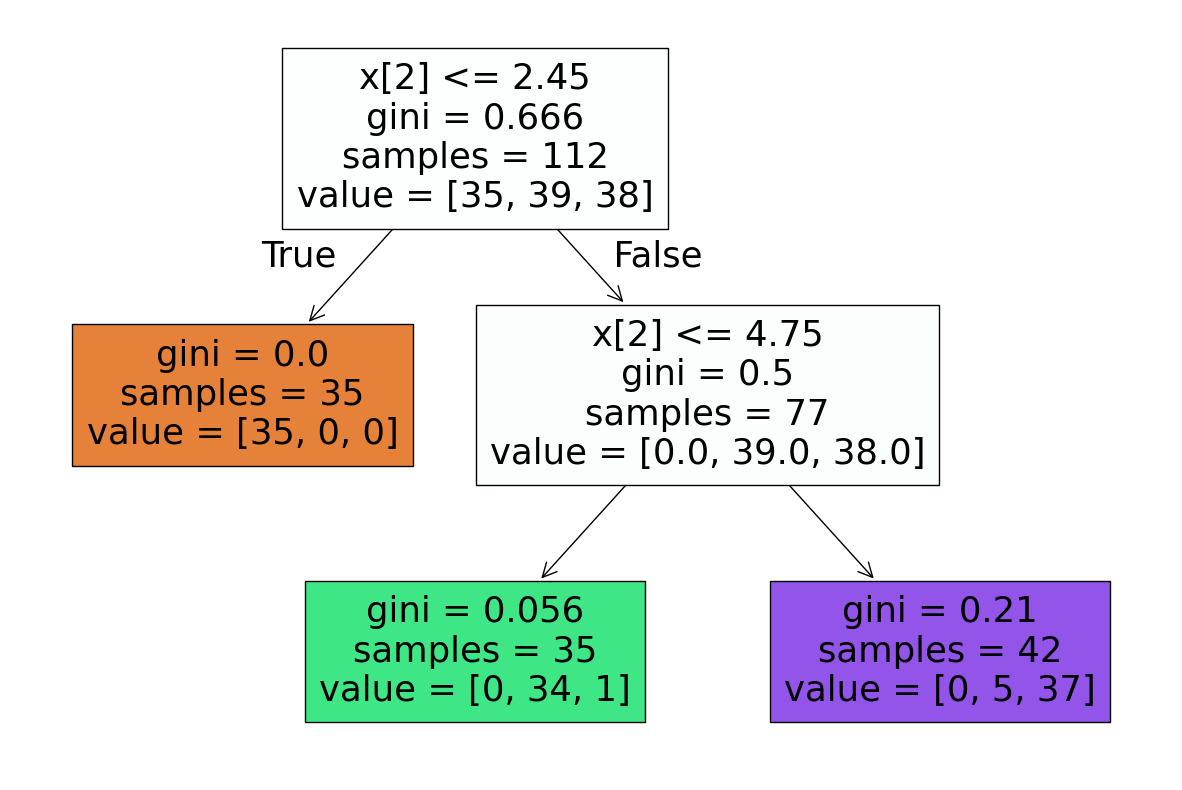

In [29]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(ds,filled=True)

In [31]:
y_pred=ds.predict(X_test)

In [32]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(Y_test,y_pred)
cr=classification_report(Y_test,y_pred)

In [33]:
print(cm)
print(cr)

[[15  0  0]
 [ 0 10  1]
 [ 0  0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.91      0.95        11
           2       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## Decision Tree Prepruining

In [34]:
params={
    'criterion':['gini', 'entropy', 'log_loss'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [35]:
params

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5],
 'max_features': ['auto', 'sqrt', 'log2']}

In [42]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=ds,param_grid=params,cv=5,scoring='accuracy')

In [43]:
grid.fit(X_train,y_train)

d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "d:\Data BootCamp\Python\venv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "d:\Data BootCamp\Python\

,estimator,DecisionTreeC...r(max_depth=2)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [44]:
y_pred=grid.predict(X_test)


In [46]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [47]:
grid.best_score_

np.float64(0.9371541501976285)

In [45]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(Y_test,y_pred)
cr=classification_report(Y_test,y_pred)
print(cm)
print(cr)

[[14  1  0]
 [ 0 11  0]
 [ 0  0 12]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.92      1.00      0.96        11
           2       1.00      1.00      1.00        12

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

